In [ ]:
! pip install datasets

In [ ]:
! pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/332.0 MB 3.1 MB/s eta 0:01:46
   ---------------------------------------- 1.3/332.0 MB 3.2 MB/s eta 0:01:44
   ---------------------------------------- 2.1/332.0 MB 3.3 MB/s eta 0:01:41
   ---------------------------------------- 2.6/332.0 MB 3.2 MB/s eta 0:01:42
   ---------------------------------------- 3.1/332.0 MB 3.0 MB/s eta 0:01:50
   ---------------------------------------- 3.7/332.0 MB 3.0 MB/s eta 0:01:51
    --------------------------------------- 4.2/332.0 MB 2.8 MB/s eta 0:01:57
    --------------------------------------- 4.5/332.0 MB 2.6 MB/s eta 0:02:06
    --------------------------------------- 4.7/332.0 MB 2.5 MB/s eta 0:02:13
    --------------------------------------- 5.0/332.0 MB 2.4 MB/s eta 0:02:15
    --------------------------------------- 5.2/332.0 MB 2.4 MB/s eta 0:02:18


In [ ]:
from datasets import load_dataset

ds = load_dataset("tblard/allocine")

README.md: 0.00B [00:00, ?B/s]

C:\Users\Admin\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\datasets--tblard--allocine. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For be

train-00000-of-00001.parquet:   0%|          | 0.00/60.0M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


validation-00000-of-00001.parquet:   0%|          | 0.00/7.58M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


test-00000-of-00001.parquet:   0%|          | 0.00/7.58M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20000 [00:00<?, ? examples/s]

In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 160000
    })
    validation: Dataset({
        features: ['review', 'label'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 20000
    })
})

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, classification_report

# Deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks, optimizers


In [ ]:
# convert train split to pandas
train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

# Quick preview
print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

(160000, 2) (20000, 2) (20000, 2)


,review,label
0,Si vous cherchez du cinéma abrutissant à tous ...,0
1,"Trash, re-trash et re-re-trash...! Une horreur...",0
2,"Et si, dans les 5 premières minutes du film, l...",0
3,Mon dieu ! Quelle métaphore filée ! Je suis ab...,0
4,"Premier film de la saga Kozure Okami, ""Le Sabr...",1


Processing Helpers

In [ ]:
#  simple text cleanup function (optional; adapte selon besoin)
import re
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # keep basic punctuation optionally
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

# apply if you want (TF-IDF can take raw text too)
train_df["text"] = train_df["review"].astype(str).map(clean_text)
val_df["text"] = val_df["review"].astype(str).map(clean_text)
test_df["text"] = test_df["review"].astype(str).map(clean_text)
y_train = train_df["label"].astype(int).values
y_val = val_df["label"].astype(int).values
y_test = test_df["label"].astype(int).values

3) Baseline: TF-IDF + Logistic Regression and SVM

In [ ]:
#  - TF-IDF + LogisticRegression
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=5, strip_accents='unicode')
lr = LogisticRegression(max_iter=1000, n_jobs=-1, solver="saga")  # saga handles L1/L2
pipe_lr = Pipeline([("tfidf", tfidf), ("clf", lr)])

print("Training Logistic Regression...")
pipe_lr.fit(train_df["text"], y_train)
pred_val_lr = pipe_lr.predict(val_df["text"])
print("Val accuracy (LR):", accuracy_score(y_val, pred_val_lr))
print(classification_report(y_val, pred_val_lr, digits=4))

# SVM (LinearSVC)
svc = LinearSVC(max_iter=5000)
pipe_svc = Pipeline([("tfidf", tfidf), ("clf", svc)])
print("Training LinearSVC (this may take longer)...")
pipe_svc.fit(train_df["text"], y_train)
pred_val_svc = pipe_svc.predict(val_df["text"])
print("Val accuracy (SVC):", accuracy_score(y_val, pred_val_svc))
print(classification_report(y_val, pred_val_svc, digits=4))


Training Logistic Regression...
Val accuracy (LR): 0.93895
              precision    recall  f1-score   support

           0     0.9459    0.9338    0.9398     10204
           1     0.9319    0.9444    0.9381      9796

    accuracy                         0.9389     20000
   macro avg     0.9389    0.9391    0.9389     20000
weighted avg     0.9390    0.9389    0.9390     20000

Training LinearSVC (this may take longer)...
Val accuracy (SVC): 0.9389
              precision    recall  f1-score   support

           0     0.9472    0.9322    0.9396     10204
           1     0.9305    0.9459    0.9381      9796

    accuracy                         0.9389     20000
   macro avg     0.9389    0.9390    0.9389     20000
weighted avg     0.9390    0.9389    0.9389     20000



4) Prepare sequences for DL models (tokenize, pad)

In [ ]:
# - Tokenizer + sequences
MAX_VOCAB = 50000
MAX_LEN = 200  # reasonable for reviews; augmente si phrases longues
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text"].tolist())

def make_seq(df_texts):
    seq = tokenizer.texts_to_sequences(df_texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_seq = make_seq(train_df["text"].tolist())
X_val_seq = make_seq(val_df["text"].tolist())
X_test_seq = make_seq(test_df["text"].tolist())

print("Shapes:", X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)


Shapes: (160000, 200) (20000, 200) (20000, 200)


5) RNN model with Embedding + BiLSTM

In [ ]:
# - RNN (Embedding + BiLSTM)
EMBED_DIM = 100

def build_rnn_model(vocab_size=MAX_VOCAB, embed_dim=EMBED_DIM, input_len=MAX_LEN, rnn_units=128, dropout=0.3):
    inp = layers.Input(shape=(input_len,))
    x = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=input_len)(inp)
    x = layers.Bidirectional(layers.LSTM(rnn_units, return_sequences=False))(x)  # no attention yet
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inputs=inp, outputs=out)
    model.compile(loss="binary_crossentropy", optimizer=optimizers.Adam(1e-3), metrics=["accuracy"])
    return model

rnn_model = build_rnn_model()
rnn_model.summary()

# callbacks
cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    callbacks.ModelCheckpoint("rnn_model.h5", save_best_only=True, monitor="val_loss")
]

history_rnn = rnn_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=8,
    batch_size=256,
    callbacks=cb
)

# eval
val_preds = (rnn_model.predict(X_val_seq) > 0.5).astype(int)
print("RNN val acc:", accuracy_score(y_val, val_preds))
print(classification_report(y_val, val_preds, digits=4))


C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 200, 100)            │       5,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 256)                 │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,251,009 (20.03 MB)

 Trainable params: 5,251,009 (20.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.8130 - loss: 0.3822  

625/625 ━━━━━━━━━━━━━━━━━━━━ 489s 780ms/step - accuracy: 0.8839 - loss: 0.2756 - val_accuracy: 0.9273 - val_loss: 0.1911
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.9493 - loss: 0.1410  

625/625 ━━━━━━━━━━━━━━━━━━━━ 473s 757ms/step - accuracy: 0.9470 - loss: 0.1452 - val_accuracy: 0.9322 - val_loss: 0.1782
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 455s 727ms/step - accuracy: 0.9661 - loss: 0.0977 - val_accuracy: 0.9325 - val_loss: 0.2140
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 432s 691ms/step - accuracy: 0.9771 - loss: 0.0686 - val_accuracy: 0.9273 - val_loss: 0.2162
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 421s 674ms/step - accuracy: 0.9845 - loss: 0.0493 - val_accuracy: 0.9251 - val_loss: 0.3006
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step
RNN val acc: 0.93215
              precision    recall  f1-score   support

           0     0.9340    0.9330    0.9335     10204
           1     0.9303    0.9313    0.9308      9796

    accuracy                         0.9322     20000
   macro avg     0.9321    0.9321    0.9321     20000
weighted avg     0.9322    0.9322    0.9322     20000



6) Bahdanau Attention layer (Keras) + model

In [ ]:
# - Bahdanau attention implementation
from tensorflow.keras.layers import Layer

class BahdanauAttention(Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = layers.Dense(units)
        self.W2 = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, query, values):
        # query shape: (batch_size, hidden)  e.g. last hidden state
        # values shape: (batch_size, seq_len, hidden_size*2) from BiLSTM with return_sequences=True
        # expand query
        query_with_time_axis = tf.expand_dims(query, 1)  # (batch, 1, hidden)
        score = self.V(tf.nn.tanh(self.W1(query_with_time_axis) + self.W2(values)))  # (batch, seq_len, 1)
        attention_weights = tf.nn.softmax(score, axis=1)  # (batch, seq_len, 1)
        context_vector = attention_weights * values  # (batch, seq_len, hidden)
        context_vector = tf.reduce_sum(context_vector, axis=1)  # (batch, hidden)
        return context_vector, tf.squeeze(attention_weights, -1)

# Build model that uses attention
def build_rnn_with_attention(vocab_size=MAX_VOCAB, embed_dim=EMBED_DIM, input_len=MAX_LEN, rnn_units=128):
    inp = layers.Input(shape=(input_len,))
    x = layers.Embedding(vocab_size, embed_dim, input_length=input_len)(inp)
    # BiLSTM with sequences so we can apply attention
    lstm_out = layers.Bidirectional(layers.LSTM(rnn_units, return_sequences=True))(x)  # (batch, seq, hidden*2)
    # use the last time step of a separate LSTM as query (or use simple mean)
    # Here, use a second BiLSTM (return_sequences=False) as query or take mean:
    # we'll get query by GlobalAveragePooling1D of lstm_out:
    query = layers.GlobalAveragePooling1D()(lstm_out)  # (batch, hidden*2)
    attention = BahdanauAttention(units=64)
    context_vector, att_weights = attention(query, lstm_out)
    x = layers.Dropout(0.3)(context_vector)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inputs=inp, outputs=out)
    model.compile(loss="binary_crossentropy", optimizer=optimizers.Adam(1e-3), metrics=["accuracy"])
    return model

att_model = build_rnn_with_attention()
att_model.summary()

cb2 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    callbacks.ModelCheckpoint("att_model.h5", save_best_only=True, monitor="val_loss")
]

history_att = att_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=8,
    batch_size=256,
    callbacks=cb2
)

# eval
val_preds_att = (att_model.predict(X_val_seq) > 0.5).astype(int)
print("Attention RNN val acc:", accuracy_score(y_val, val_preds_att))
print(classification_report(y_val, val_preds_att, digits=4))


C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 200)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_1 (Embedding)       │ (None, 200, 100)          │       5,000,000 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_1               │ (None, 200, 256)          │         234,496 │ embedding_1[0][0]          │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d      │ (None, 256)               │               0 │ bidirectional_1[0][0]      │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bahdanau_attention            │ [(None, 256), (None,      │          32,961 │ global_average_pooling1d[… │
│ (BahdanauAttention)           │ 200)]                     │                 │ bidirectional_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 256)               │               0 │ bahdanau_attention[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 64)                │          16,448 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 64)                │               0 │ dense_5[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 1)                 │              65 │ dropout_3[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 5,283,970 (20.16 MB)

 Trainable params: 5,283,970 (20.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8071 - loss: 0.3791     

625/625 ━━━━━━━━━━━━━━━━━━━━ 666s 1s/step - accuracy: 0.8836 - loss: 0.2658 - val_accuracy: 0.9309 - val_loss: 0.1790
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9519 - loss: 0.1318   

625/625 ━━━━━━━━━━━━━━━━━━━━ 762s 1s/step - accuracy: 0.9513 - loss: 0.1326 - val_accuracy: 0.9360 - val_loss: 0.1702
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 549s 878ms/step - accuracy: 0.9698 - loss: 0.0866 - val_accuracy: 0.9330 - val_loss: 0.1816
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 517s 828ms/step - accuracy: 0.9807 - loss: 0.0571 - val_accuracy: 0.9290 - val_loss: 0.2149
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 517s 826ms/step - accuracy: 0.9869 - loss: 0.0395 - val_accuracy: 0.9283 - val_loss: 0.2451
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step
Attention RNN val acc: 0.936
              precision    recall  f1-score   support

           0     0.9490    0.9242    0.9365     10204
           1     0.9232    0.9482    0.9355      9796

    accuracy                         0.9360     20000
   macro avg     0.9361    0.9362    0.9360     20000
weighted avg     0.9363    0.9360    0.9360     20000



Notes sur l’attention :

Ici j’ai utilisé une GlobalAveragePooling sur la sortie séquence du BiLSTM pour produire la query (simple et robuste). Tu peux aussi utiliser la dernière LSTM state comme query si tu retournes return_state=True sur une LSTM séparée.

La couche BahdanauAttention fournie renvoie aussi les poids d’attention si tu veux les visualiser (utile pour interprétabilité).

7) Comparaison & métriques finales (test set)

In [ ]:
#  - evaluate everything on test set
def eval_model(pipe_or_model, X_test, y_test, is_pipeline=False):
    if is_pipeline:
        preds = pipe_or_model.predict(X_test)
        probs = None
    else:
        probs = pipe_or_model.predict(X_test)
        preds = (probs > 0.5).astype(int)
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='binary')
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "preds": preds, "probs": probs}

results = {}
results["LR"] = eval_model(pipe_lr, test_df["text"], y_test, is_pipeline=True)
results["SVC"] = eval_model(pipe_svc, test_df["text"], y_test, is_pipeline=True)
results["RNN"] = eval_model(rnn_model, X_test_seq, y_test, is_pipeline=False)
results["AttRNN"] = eval_model(att_model, X_test_seq, y_test, is_pipeline=False)

for name, res in results.items():
    print(f"--- {name} ---")
    print(f"acc={res['accuracy']:.4f}  prec={res['precision']:.4f}  rec={res['recall']:.4f}  f1={res['f1']:.4f}")


625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step
--- LR ---
acc=0.9406  prec=0.9354  rec=0.9412  f1=0.9383
--- SVC ---
acc=0.9430  prec=0.9368  rec=0.9450  f1=0.9408
--- RNN ---
acc=0.9353  prec=0.9343  rec=0.9305  f1=0.9324
--- AttRNN ---
acc=0.9375  prec=0.9289  rec=0.9417  f1=0.9353


8) Visualisation des courbes d'entraînement (facultatif)

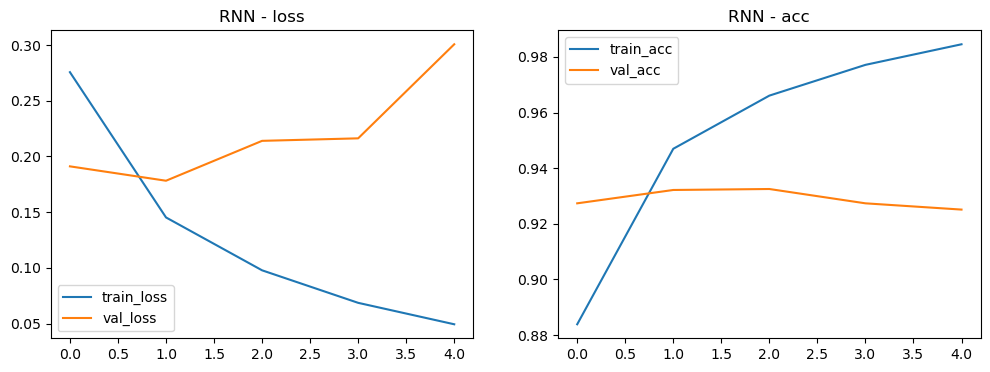

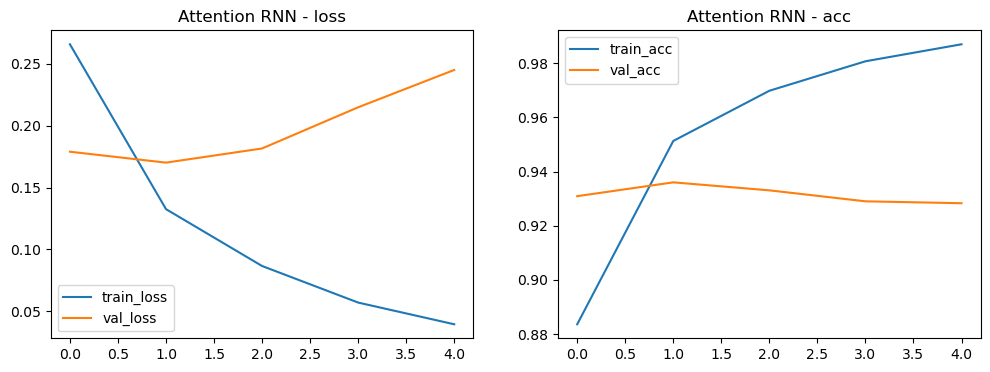

In [ ]:
#- plot train/val loss/accuracy for RNNs
def plot_history(h, title="history"):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(h.history["loss"], label="train_loss")
    plt.plot(h.history["val_loss"], label="val_loss")
    plt.title(title + " - loss"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(h.history["accuracy"], label="train_acc")
    plt.plot(h.history["val_accuracy"], label="val_acc")
    plt.title(title + " - acc"); plt.legend()
    plt.show()

plot_history(history_rnn, "RNN")
plot_history(history_att, "Attention RNN")
